In [1]:
from pathlib import Path

from pff import config_dir
from pff.config_classes.node_pk_config import NodePKConfig
from pff.config_classes.flow_pk_config import FlowPKConfig
from pff.data.datasets.aicme_datasets import (
    AICMECompartmentsDataBatch,
    AICMECompartmentsDataModule,
)
from pff.utils.plots import plot_list_aicme_databatch
from pff.utils.plots.databatch_plot import plot_list_aicme_databatch

# Sample and Plot

In [2]:
default_yaml = Path(config_dir) / "experiment_configs" / "UAI"/ "flow-pk-predictive" / "flowPK.yaml"
default_yaml = Path(config_dir) / "experiment_configs" / "UAI"/ "flow-pk-predict-n-generate-test" / "flowPK.yaml"

#default_yaml = Path(config_dir) / "experiment_configs" / "node-pk" / "cvaeNoDose.yaml"
#default_yaml = Path(config_dir) / "experiment_configs" / "node-pk" / "base-homogeneous.yaml"
#default_yaml = Path(config_dir) / "experiment_configs" / "node-pk" / "predictionPK.yaml"

cfg: FlowPKConfig = FlowPKConfig.from_yaml(str(default_yaml))

In [11]:
# 2) Build data module and materialize datasets
dm = AICMECompartmentsDataModule(cfg)
dm.prepare_data()
dm.setup()
loader = dm.train_dataloader()
batches = next(iter(loader))
batch:AICMECompartmentsDataBatch = batches[0]

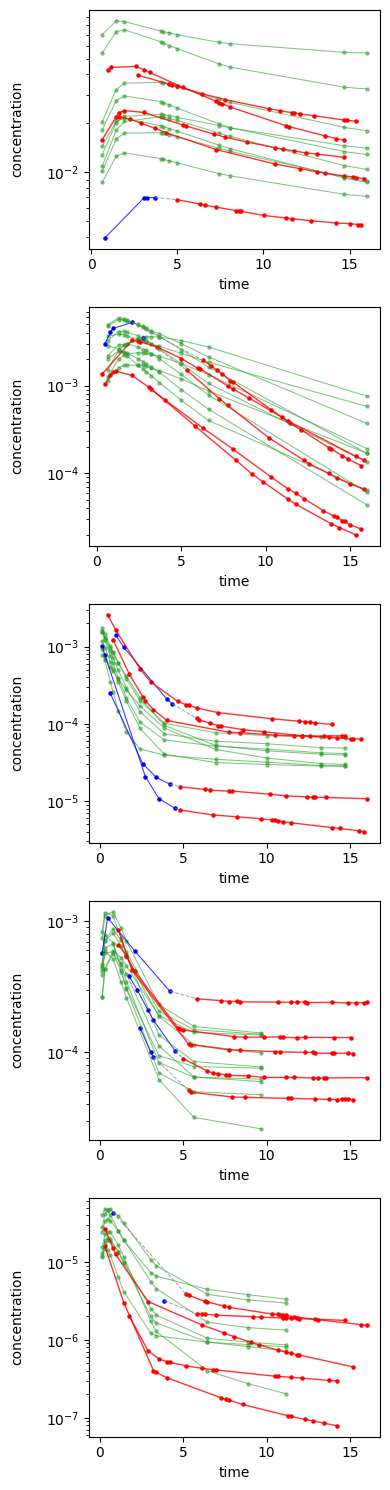

In [4]:
%matplotlib inline
plot_list_aicme_databatch(batches,number_of_columns=5,number_of_rows=5)

# PLOT EMPIRICAL

In [10]:
empirical_databatches = dm.get_empirical_test_batches(no_heldout=False)
empirical_databatches.keys()
databatch_list = empirical_databatches['cesarali/Indometacin']
databatch = databatch_list[0]



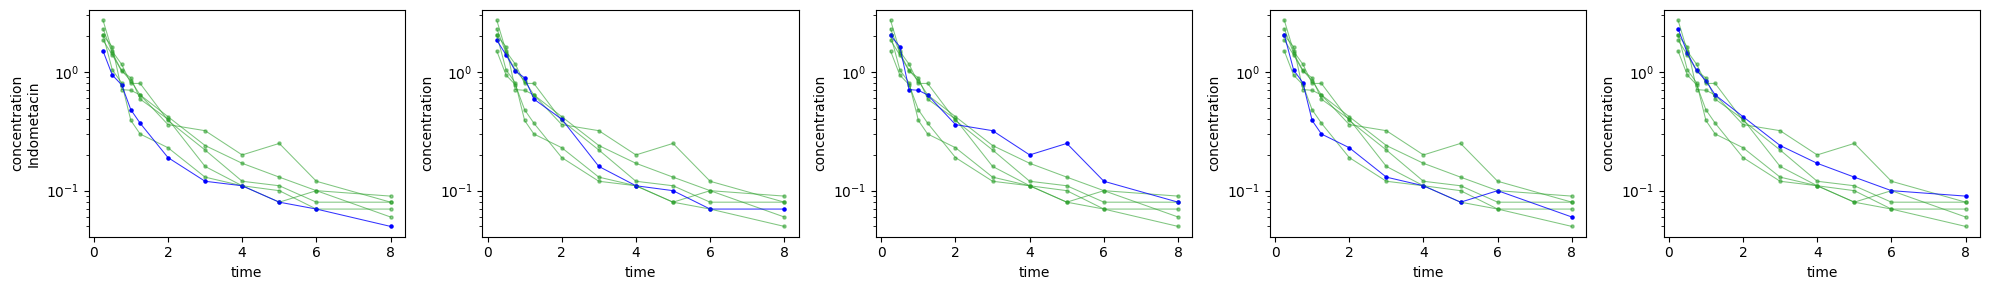

In [6]:
%matplotlib inline

plot_list_aicme_databatch(databatch_list,number_of_columns=5,number_of_rows=5)

<!-- # To Study JSON -->